# DQN Clean Implementation from Scratch

The materials are reused from: https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html

In [1]:
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from IPython import display
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

## Create Environment

In [2]:
env = gym.make("CartPole-v1") # cartpole environment
device = torch.device("cpu")

## Create Replay Memory

In [3]:
# use of named tuple
# namedtuple is fancy tuple (Set()) having name for each element
# helps in debugging
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

# replay memory: This will store transistions which will be used
class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

## Q-Network Agent

In [4]:
# Q-Network
class QNetwork(nn.Module):
    def __init__(self, n_observations, n_actions):
        super().__init__()
        self.layer1 = nn.Linear(n_observations, 32)
        self.layer2 = nn.Linear(32, 32)
        self.layer3 = nn.Linear(32, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)   # Q(s, ·)

class Agent(nn.Module):
    def __init__(self, n_observations, n_actions, **kwargs):
        super().__init__()
        self.n_actions = n_actions
        self.device = kwargs.get("device", torch.device("cpu"))

        self.dqn = QNetwork(n_observations, n_actions).to(self.device)

        self.steps_done = 0
        self.EPS_START = kwargs.get("EPS_START", 1.0)
        self.EPS_END   = kwargs.get("EPS_END",   0.1)
        self.EPS_DECAY = kwargs.get("EPS_DECAY", 10000)
        self.TAU       = kwargs.get("TAU",       0.005)
        self.LR        = kwargs.get("LR",        1e-4)
        self.GAMMA     = kwargs.get("GAMMA",     0.99)
        self.BATCH_SIZE= kwargs.get("BATCH_SIZE",128)

    def forward(self, x):
        # x can be np.array or tensor, 1D or 2D; normalize to (B, obs)
        x = torch.as_tensor(x, dtype=torch.float32, device=self.device)
        if x.dim() == 1:
            x = x.unsqueeze(0)
        return self.dqn(x)

    @torch.no_grad()
    def select_action(self, state):
        """Epsilon-greedy action selection; returns tensor shape (1, 1)."""
        # epsilon schedule
        eps = self.EPS_END + (self.EPS_START - self.EPS_END) * \
              math.exp(-self.steps_done / self.EPS_DECAY)
        self.steps_done += 1

        if random.random() > eps:
            q = self.forward(state)                       # (1, n_actions)
            action = q.argmax(dim=1, keepdim=True)        # (1, 1) long
        else:
            action = torch.randint(self.n_actions, (1, 1),
                                   device=self.device, dtype=torch.long)
        return action  # optionally also return eps for logging


In [5]:

# BATCH_SIZE is the number of transitions sampled from the replay buffer
# GAMMA is the discount factor as mentioned in the previous section
# EPS_START is the starting value of epsilon
# EPS_END is the final value of epsilon
# EPS_DECAY controls the rate of exponential decay of epsilon, higher means a slower decay
# TAU is the update rate of the target network
# LR is the learning rate of the ``AdamW`` optimizer

hyperparameters = {
    "BATCH_SIZE": 128,
    "GAMMA": 0.99,
    "EPS_START": 0.9,
    "EPS_END": 0.05,
    "EPS_DECAY": 1000,
    "TAU": 0.005,
    "LR": 1e-4
}

# Discrete actions
n_actions = env.action_space.n

# Reset (Gymnasium returns (obs, info); old Gym returns obs)
obs = env.reset()
state = obs[0] if isinstance(obs, tuple) else obs

# Robust observation dimension (works for vector observations)
try:
    n_observations = int(np.prod(env.observation_space.shape))
except Exception:
    n_observations = state.size if hasattr(state, "size") else len(state)

# Policy (Agent owns its Q-network and device)
policy_net = Agent(n_observations, n_actions, device=device, **hyperparameters)

# Target network: just the Q-network replica (no need for a full Agent here)
target_net = QNetwork(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.dqn.state_dict())
target_net.eval()  # targets are computed without grads

# Optimizer over the policy network params
optimizer = optim.AdamW(policy_net.parameters(), lr=policy_net.LR, amsgrad=True)

# Replay buffer
memory = ReplayMemory(10000)


## Training

## DQN: Target, Loss, and Minimal Training Steps

**Mini-batch notation.** Sample a batch $\mathcal{B}=\{(s_i,a_i,r_i,s'_i)\}_{i=1}^B$.
Let $m_i=1$ if $s'_i$ is **non-terminal** (your code uses `None` for terminals), else $m_i=0$.
Policy network $Q_\theta$, target network $Q_{\bar\theta}$.

**Current Q for taken actions (gather):**
$$
q_i \;=\; Q_\theta(s_i, a_i).
$$

**One-step bootstrap value (via target net):**
$$
v'_i \;=\; \max_{a'}\, Q_{\bar\theta}(s'_i, a').
$$

**TD target (mask terminals):**
$$
y_i \;=\; r_i \;+\; \gamma \, m_i \, v'_i.
$$

**Huber (SmoothL1) loss over the batch:**
$$
L(\theta) \;=\; \frac{1}{B}\sum_{i=1}^B \rho\!\big(q_i - y_i\big), \quad
\rho(e)=
\begin{cases}
\frac{1}{2}e^2, & |e|<1,\\
|e|-\frac{1}{2}, & \text{otherwise.}
\end{cases}
$$

**Gradient step:**
$$
\theta \;\leftarrow\; \theta \;-\; \alpha \,\nabla_\theta L(\theta).
$$

**Soft target update (each step):**
$$
\bar\theta \;\leftarrow\; \tau\,\theta \;+\; (1-\tau)\,\bar\theta.
$$

### Minimal training steps (what the loop does)
1. **Act** with $\epsilon$-greedy from $Q_\theta$: get $(s,a,r,s')$.
2. **Store** transition in replay.
3. **Sample** a minibatch once $|\mathcal{D}|\ge B$.
4. **Compute** $q_i = Q_\theta(s_i,a_i)$ and $v'_i = \max_{a'} Q_{\bar\theta}(s'_i,a')$.
5. **Build targets** $y_i = r_i + \gamma m_i v'_i$.
6. **Optimize** SmoothL1 loss $L(\theta)$ (clip grads).
7. **Update target** $\bar\theta \leftarrow \tau\theta + (1-\tau)\bar\theta$.
8. **Repeat** until episode ends; log episode return/length.


In [6]:

# Shorthands from the Agent (so there's a single source of truth)
device      = policy_net.device
BATCH_SIZE  = policy_net.BATCH_SIZE
GAMMA       = policy_net.GAMMA
TAU         = policy_net.TAU


num_episodes = 50
episode_returns = []
episode_lengths = []

criterion = nn.SmoothL1Loss()

for i_episode in range(num_episodes):
    # Reset env
    obs = env.reset()
    state = obs[0] if isinstance(obs, tuple) else obs
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

    ep_return = 0.0

    for t in count():  # run until done
        # --- Act ---
        action = policy_net.select_action(state)              # (1,1) long
        next_obs, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        reward_t = torch.tensor([reward], device=device)
        ep_return += float(reward)

        # Next-state tensor or None for terminal
        if done:
            next_state = None
        else:
            next_state = torch.tensor(next_obs, dtype=torch.float32, device=device).unsqueeze(0)

        # --- Store transition ---
        memory.push(state, action, next_state, reward_t)

        # Move to next state
        state = next_state

        # --- Inline optimization (only when we have enough samples) ---
        if len(memory) >= BATCH_SIZE:
            transitions = memory.sample(BATCH_SIZE)
            batch = Transition(*zip(*transitions))

            # Build masks and tensors
            non_final_mask = torch.tensor(tuple(s is not None for s in batch.next_state),
                                          device=device, dtype=torch.bool)
            non_final_next_states = torch.cat([s for s in batch.next_state if s is not None]) \
                                     if non_final_mask.any() else None

            state_batch  = torch.cat(batch.state)             # [B, obs]
            action_batch = torch.cat(batch.action)            # [B, 1] (long)
            reward_batch = torch.cat(batch.reward)            # [B]

            # Q(s_t, a_t)
            state_action_values = policy_net(state_batch).gather(1, action_batch).squeeze(1)  # [B]

            # Bootstrap values Q(s_{t+1})
            next_state_values = torch.zeros(BATCH_SIZE, device=device)                        # [B]
            with torch.no_grad():
                if non_final_mask.any():
                    q_next = target_net(non_final_next_states)                                # [B', A]
                    next_state_values[non_final_mask] = q_next.max(1).values                 # [B']

            # Targets: r + gamma * V(next)
            expected_state_action_values = reward_batch + GAMMA * next_state_values          # [B]

            # Loss & update
            loss = criterion(state_action_values, expected_state_action_values)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
            optimizer.step()

            # Soft target update: θ^- ← τ θ + (1−τ) θ^-
            with torch.no_grad():
                tgt_sd = target_net.state_dict()
                pol_sd = policy_net.dqn.state_dict()
                for k in pol_sd:
                    tgt_sd[k] = pol_sd[k]*TAU + tgt_sd[k]*(1 - TAU)
                target_net.load_state_dict(tgt_sd)

        if done:
            episode_returns.append(ep_return)
            episode_lengths.append(t + 1)
            break

print("Training complete.")


Training complete.


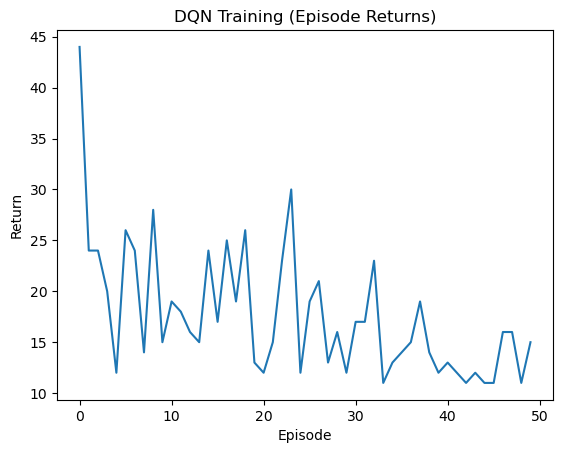

In [7]:
plt.figure()
plt.plot(episode_returns)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("DQN Training (Episode Returns)")
plt.show()


## Evaluate

In [8]:

def eval_policy(policy_net, env, episodes=5):
    """Greedy evaluation: average return over `episodes` (no exploration)."""
    device = policy_net.device
    policy_net.eval()
    avg_return = 0.0

    with torch.no_grad():
        for _ in range(episodes):
            obs, _ = env.reset()
            s = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            done = False
            while not done:
                a = policy_net(s).argmax(dim=1).item()             # greedy
                obs, r, terminated, truncated, _ = env.step(a)     # Gymnasium 0.26+
                avg_return += float(r)
                done = terminated or truncated
                if not done:
                    s = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

    policy_net.train()  # remove if you're not training elsewhere
    return avg_return / episodes

# Example:
avg_ret = eval_policy(policy_net, env, episodes=10)
print(f"Average return over 10 eval episodes: {avg_ret:.2f}")


Average return over 10 eval episodes: 9.60
